#  Prediksi Risiko Kecelakaan Kerja — PT Besli Manufacturing

**Studi Kasus:** PT Besli Manufacturing mengalami beberapa insiden kecelakaan kerja dalam beberapa tahun terakhir. Tim HR dan keselamatan ingin mengembangkan **sistem prediktif berbasis data historis** untuk mencegah kecelakaan lebih lanjut dan menjaga keselamatan karyawan.

**Tujuan:** Memprediksi apakah seorang karyawan berisiko mengalami kecelakaan kerja berdasarkan fitur: usia, jam kerja per minggu, pengalaman tahun, pelatihan K3, shift, jabatan, dan lokasi kerja.

---

##  Alur Analisis
1. Import Library
2. Load & Eksplorasi Data (EDA)
3. Preprocessing Data
4. Pemodelan Machine Learning
5. Evaluasi Model
6. Feature Importance
7. Kesimpulan & Rekomendasi

---
## 1.  Import Library

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

---
## 2.  Load & Eksplorasi Data (EDA)

In [238]:
df = pd.read_csv('dataset_kecelakaan.csv')

In [239]:
df.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


In [240]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    300 non-null    int64
 1   Usia                  300 non-null    int64
 2   Jam_Kerja_per_Minggu  300 non-null    int64
 3   Pengalaman_Tahun      300 non-null    int64
 4   Pelatihan_K3          300 non-null    str  
 5   Shift                 300 non-null    str  
 6   Jabatan               300 non-null    str  
 7   Lokasi                300 non-null    str  
 8   Kecelakaan            300 non-null    int64
dtypes: int64(5), str(4)
memory usage: 21.2 KB


In [241]:
df.describe().round(2)

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.00,300.00,300.00,300.00,300.00
mean,150.50,40.38,44.78,17.75,0.28
std,86.75,12.12,6.60,10.93,0.45
min,1.00,15.00,10.00,1.00,0.00
25%,75.75,30.00,41.00,8.00,0.00
50%,150.50,42.00,45.00,18.00,0.00
75%,225.25,51.00,48.00,27.00,1.00
max,300.00,70.00,100.00,60.00,1.00


In [242]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing Values:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values:
Series([], dtype: int64)

Total missing values: 0


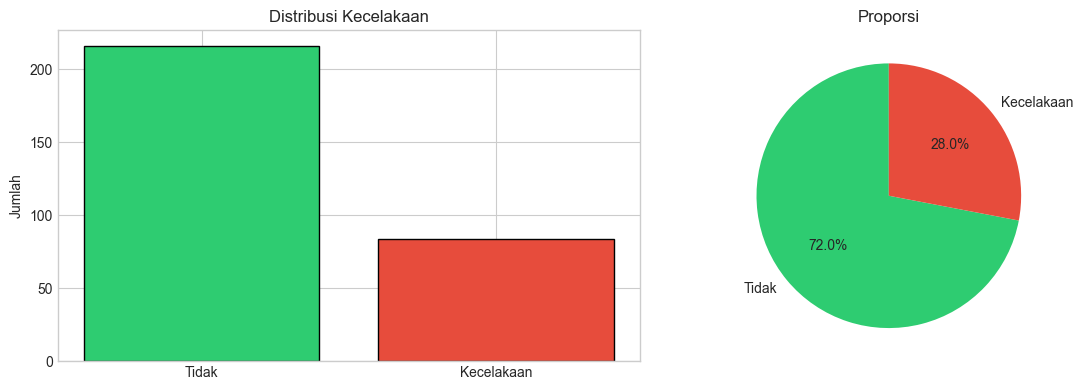

In [243]:
labels = ['Tidak', 'Kecelakaan']
values = df['Kecelakaan'].value_counts().sort_index().values

colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax[0].bar(labels, values, color=colors, edgecolor='black')
ax[0].set_title('Distribusi Kecelakaan')
ax[0].set_ylabel('Jumlah')

# Pie chart
ax[1].pie(values, labels=labels,
          autopct='%1.1f%%',
          startangle=90,
          colors=colors)

ax[1].set_title('Proporsi')

plt.tight_layout()
plt.show()

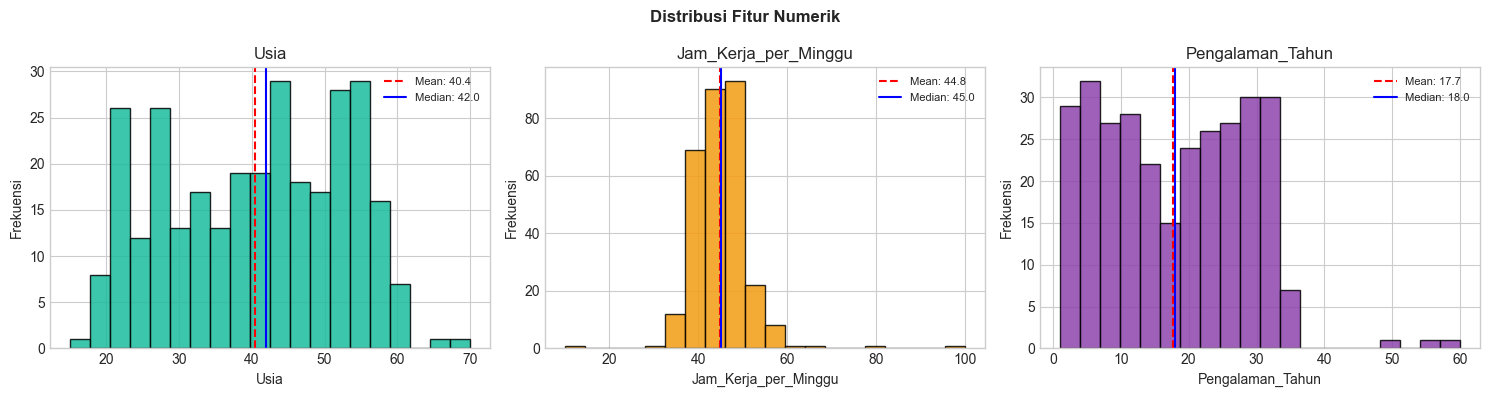

In [244]:
num_cols = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']
colors = ['#1abc9c', '#f39c12', '#8e44ad'] 

fig, ax = plt.subplots(1, len(num_cols), figsize=(15, 4))

for i, col in enumerate(num_cols):
    data = df[col]

    ax[i].hist(data, bins=20,
               color=colors[i],
               edgecolor='black', alpha=0.85)

    # Mean
    ax[i].axvline(data.mean(),
                  color='red', linestyle='--',
                  label=f"Mean: {data.mean():.1f}")

    # Median (tambahan biar lebih keren)
    ax[i].axvline(data.median(),
                  color='blue', linestyle='-',
                  label=f"Median: {data.median():.1f}")

    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Frekuensi')
    ax[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

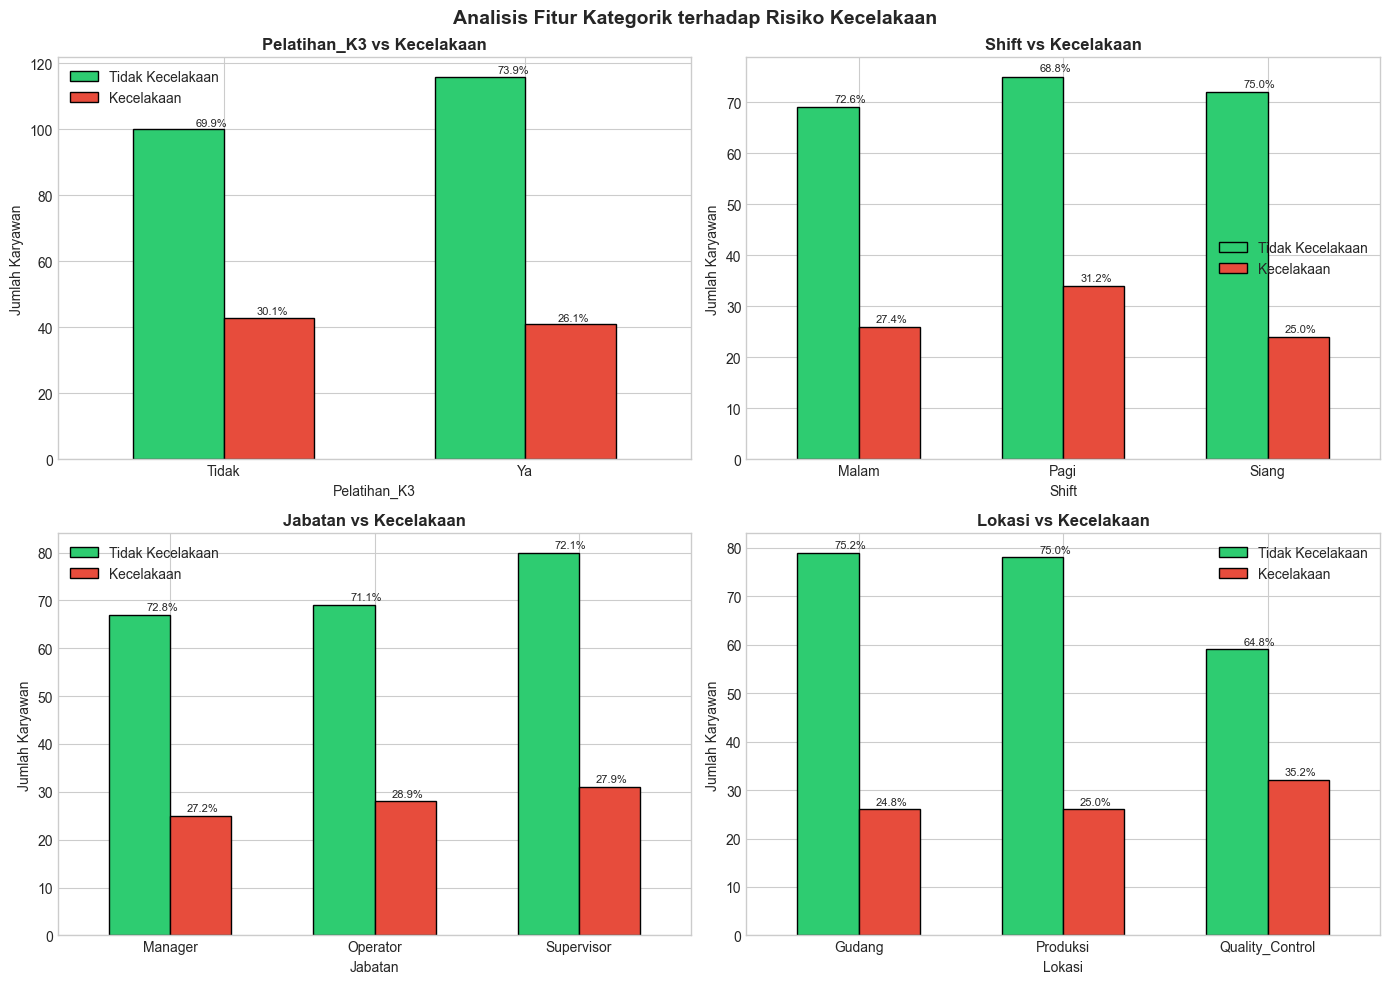

In [245]:
cat_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten()

colors = ['#2ecc71', '#e74c3c']  

for i, col in enumerate(cat_cols):

    cross_count = pd.crosstab(df[col], df['Kecelakaan'])

    cross_pct = pd.crosstab(df[col], df['Kecelakaan'], normalize='index') * 100

    cross_pct.columns   = ['Tidak', 'Kecelakaan']

    cross_count.plot(kind='bar',
                     ax=ax[i],
                     color=colors,
                     edgecolor='black',
                     width=0.6)

    for j, category in enumerate(cross_count.index):
        for k, cls in enumerate(cross_count.columns):
            value = cross_count.iloc[j, k]
            pct   = cross_pct.iloc[j, k]

            ax[i].text(j + (k-0.2)*0.2,
                       value + 1,
                       f'{pct:.1f}%',
                       ha='center',
                       fontsize=8)

    ax[i].set_title(f'{col} vs Kecelakaan', fontweight='bold')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Jumlah Karyawan')

    ax[i].tick_params(axis='x', rotation=0)
    ax[i].legend(['Tidak Kecelakaan', 'Kecelakaan'])

plt.suptitle('Analisis Fitur Kategorik terhadap Risiko Kecelakaan',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

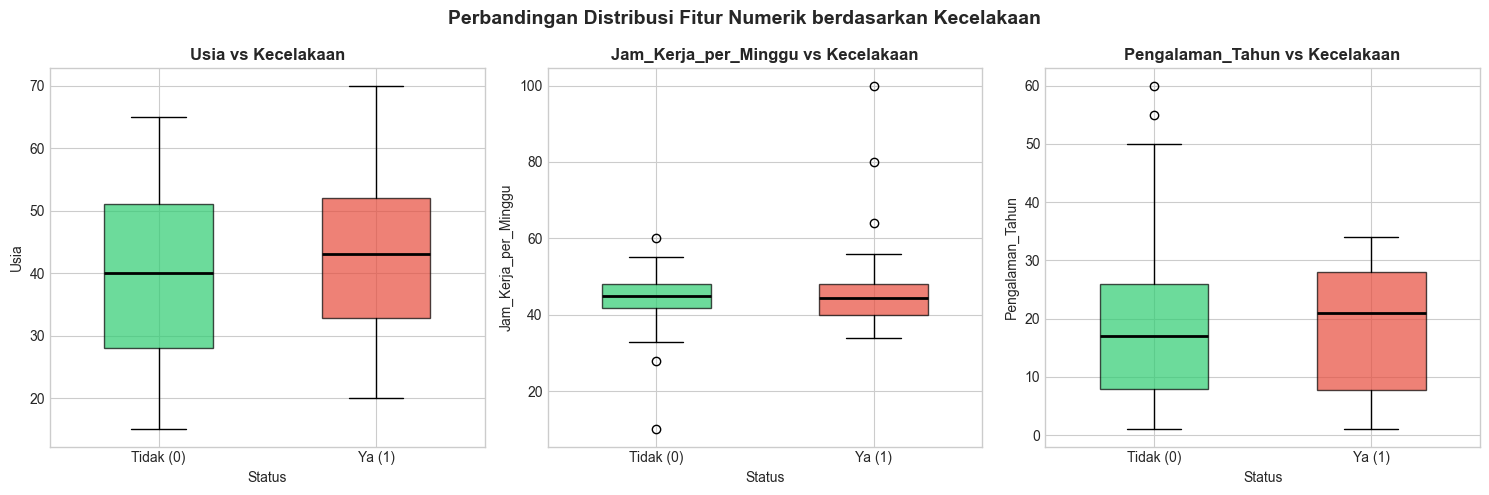

In [246]:
fig, ax = plt.subplots(1, len(num_cols), figsize=(15, 5))

colors = ["#2ecc71", "#e74c3c"]  # hijau = aman, merah = kecelakaan

for i, col in enumerate(num_cols):
    
    # pisahkan data per kelas
    data_aman = df[df['Kecelakaan'] == 0][col]
    data_kecelakaan = df[df['Kecelakaan'] == 1][col]

    data = [data_aman, data_kecelakaan]

    bp = ax[i].boxplot(data,
                       patch_artist=True,
                       widths=0.5)

    # warna box
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # median line lebih tebal
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    # judul & label
    ax[i].set_title(f'{col} vs Kecelakaan', fontweight='bold')
    ax[i].set_xlabel('Status')
    ax[i].set_ylabel(col)

    ax[i].set_xticklabels(['Tidak (0)', 'Ya (1)'])

plt.suptitle('Perbandingan Distribusi Fitur Numerik berdasarkan Kecelakaan',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

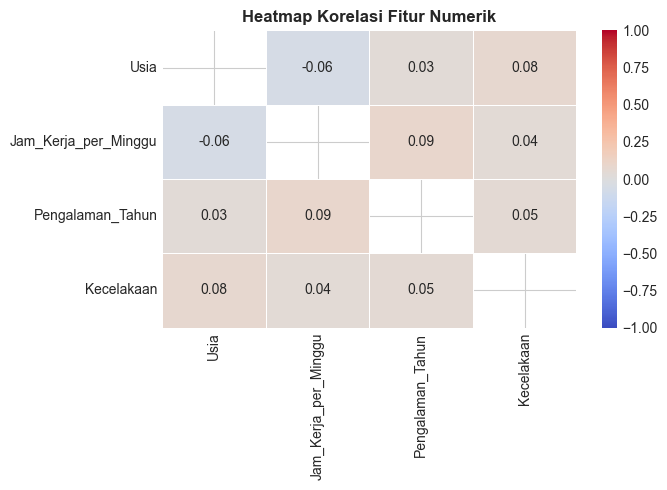

In [247]:
corr = df[num_cols + ['Kecelakaan']].corr()

mask = np.eye(len(corr), dtype=bool)

plt.figure(figsize=(7, 5))
sns.heatmap(corr,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            vmin=-1, vmax=1,
            annot_kws={'size': 10})

plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Soal 2 — Feature Engineering dalam Machine Learning
> **(20 Poin · CLO-4)**

## Pengertian Feature Engineering

**Feature Engineering** adalah proses mengolah, mengubah, dan membentuk fitur (variabel input) dari data mentah agar model *Machine Learning* mampu memahami pola data dengan lebih baik dan menghasilkan prediksi yang lebih akurat.

Feature engineering yang efektif sering kali memberikan dampak yang lebih besar terhadap performa model dibandingkan hanya sekadar memilih algoritma. Oleh karena itu, tahap ini menjadi bagian penting dalam proses pengolahan data.

Proses feature engineering umumnya terdiri dari beberapa tahapan utama sebagai berikut:

| No | Tahapan               | Penjelasan                                                                                     |
|----|----------------------|-------------------------------------------------------------------------------------------------|
| 1  | **Feature Selection** | Kolom ID dihapus karena hanya sebagai identitas dan tidak berpengaruh pada prediksi            |
| 2  | **Feature Encoding**  | Fitur kategorik diubah menjadi numerik menggunakan Label Encoding agar dapat diproses model   |
| 3  | **Feature Scaling**   | Fitur numerik dinormalisasi menggunakan StandardScaler agar tidak terjadi bias antar fitur     |
| 4  | **Feature Creation**  | Dibuat fitur baru seperti *Beban_Kerja* dan *Kategori_Usia* untuk menangkap pola yang lebih kompleks |

### Penerapan Feature Engineering pada Studi Kasus PT Besli Manufacturing

#### 1. Feature Selection — Membuang Kolom ID
Kolom `ID` dibuang karena hanya berfungsi sebagai **pengenal unik karyawan** — tidak memiliki hubungan sebab-akibat dengan risiko kecelakaan. Menyertakan ID justru bisa menyebabkan *overfitting*.

In [248]:
df_fe = df.copy()

cols_before = df_fe.columns.tolist()

df_fe.drop(columns=['ID'], inplace=True)

cols_after = df_fe.columns.tolist()

print("=== Feature Selection ===")
print(f"Jumlah kolom sebelum: {len(cols_before)}")
print(f"Jumlah kolom setelah: {len(cols_after)}")

print("\nKolom sebelum:")
print(cols_before)

print("\nKolom setelah:")
print(cols_after)

print("\nKeterangan:")
print("Kolom 'ID' dihapus karena hanya sebagai identitas unik dan tidak relevan untuk prediksi.")
print("Penggunaan ID dapat menyebabkan overfitting karena model hanya menghafal data.")

=== Feature Selection ===
Jumlah kolom sebelum: 9
Jumlah kolom setelah: 8

Kolom sebelum:
['ID', 'Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan']

Kolom setelah:
['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan']

Keterangan:
Kolom 'ID' dihapus karena hanya sebagai identitas unik dan tidak relevan untuk prediksi.
Penggunaan ID dapat menyebabkan overfitting karena model hanya menghafal data.


#### 2. Feature Encoding — Label Encoding untuk Fitur Kategorik
Empat fitur kategorik (`Pelatihan_K3`, `Shift`, `Jabatan`, `Lokasi`) diubah menjadi angka menggunakan **Label Encoding**, karena algoritma ML tidak bisa memproses teks secara langsung.

In [249]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

print("=" * 60)
print(" FEATURE ENCODING — KATEGORIK → NUMERIK")
print("=" * 60)

encoders = {} 

for col in cat_cols:
    le = LabelEncoder() 
    df_fe[col] = le.fit_transform(df_fe[col])
    
    encoders[col] = le 
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col:<20} → {mapping}")

print("\nCuplikan data setelah encoding:")
print(df_fe.head(4))

 FEATURE ENCODING — KATEGORIK → NUMERIK
Pelatihan_K3         → {'Tidak': np.int64(0), 'Ya': np.int64(1)}
Shift                → {'Malam': np.int64(0), 'Pagi': np.int64(1), 'Siang': np.int64(2)}
Jabatan              → {'Manager': np.int64(0), 'Operator': np.int64(1), 'Supervisor': np.int64(2)}
Lokasi               → {'Gudang': np.int64(0), 'Produksi': np.int64(1), 'Quality_Control': np.int64(2)}

Cuplikan data setelah encoding:
   Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun  Pelatihan_K3  Shift  Jabatan  \
0    58                    47                10             1      1        2   
1    48                    44                17             0      2        2   
2    34                    40                22             1      1        0   
3    27                    37                26             0      0        0   

   Lokasi  Kecelakaan  
0       0           0  
1       0           0  
2       0           0  
3       0           0  


#### 3. Feature Scaling — StandardScaler pada Fitur Numerik
Fitur `Usia` (rentang 15–70), `Jam_Kerja_per_Minggu` (35–60), dan `Pengalaman_Tahun` (1–60) memiliki skala berbeda. Tanpa scaling, model seperti **SVM** dan **KNN** akan bias terhadap fitur berskala besar.

**StandardScaler** mentransformasi setiap nilai menjadi distribusi dengan mean=0 dan std=1:

$$z = \frac{x - \mu}{\sigma}$$

In [250]:
from sklearn.preprocessing import StandardScaler

num_features = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

print("=" * 50)
print(" SEBELUM StandardScaler")
print("=" * 50)
print(df_fe[num_features].describe().round(2))

# copy data
df_scaled = df_fe.copy()

# scaling
scaler = StandardScaler()
df_scaled[num_features] = scaler.fit_transform(df_fe[num_features])

print("\n" + "=" * 50)
print(" SETELAH StandardScaler (mean ≈ 0, std ≈ 1)")
print("=" * 50)
print(df_scaled[num_features].describe().round(3))

 SEBELUM StandardScaler
         Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun
count  300.00                300.00            300.00
mean    40.38                 44.78             17.75
std     12.12                  6.60             10.93
min     15.00                 10.00              1.00
25%     30.00                 41.00              8.00
50%     42.00                 45.00             18.00
75%     51.00                 48.00             27.00
max     70.00                100.00             60.00

 SETELAH StandardScaler (mean ≈ 0, std ≈ 1)
          Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun
count  300.000               300.000           300.000
mean     0.000                -0.000             0.000
std      1.002                 1.002             1.002
min     -2.098                -5.280            -1.535
25%     -0.858                -0.574            -0.893
50%      0.134                 0.033             0.023
75%      0.878                 0.489             0.848
max  

#### 4. Feature Creation — Membuat Fitur Baru (Pengembangan)
Dari fitur yang ada, kita dapat menciptakan fitur turunan baru untuk menangkap pola yang lebih kompleks dan tidak terlihat secara langsung.

In [251]:
df_new = df.copy()

df_new['Beban_Kerja'] = df_new['Jam_Kerja_per_Minggu'] / (df_new['Pengalaman_Tahun'] + 1)

bins_usia = [0, 30, 50, 100]
labels_usia = ['Muda (≤30)', 'Paruh Baya (31-50)', 'Senior (>50)']

df_new['Kategori_Usia'] = pd.cut(
    df_new['Usia'],
    bins=bins_usia,
    labels=labels_usia,
    include_lowest=True
)

print("=== FEATURE CREATION ===")

print("\nStatistik Beban_Kerja:")
print(df_new['Beban_Kerja'].describe().round(3))

print("\nDistribusi Kategori_Usia vs Kecelakaan:")
print(pd.crosstab(df_new['Kategori_Usia'], df_new['Kecelakaan'],
                  margins=True, margins_name='Total'))

=== FEATURE CREATION ===

Statistik Beban_Kerja:
count    300.000
mean       4.294
std        4.529
min        0.294
25%        1.574
50%        2.375
75%        5.000
max       27.500
Name: Beban_Kerja, dtype: float64

Distribusi Kategori_Usia vs Kecelakaan:
Kecelakaan            0   1  Total
Kategori_Usia                     
Muda (≤30)           63  18     81
Paruh Baya (31-50)   97  40    137
Senior (>50)         56  26     82
Total               216  84    300


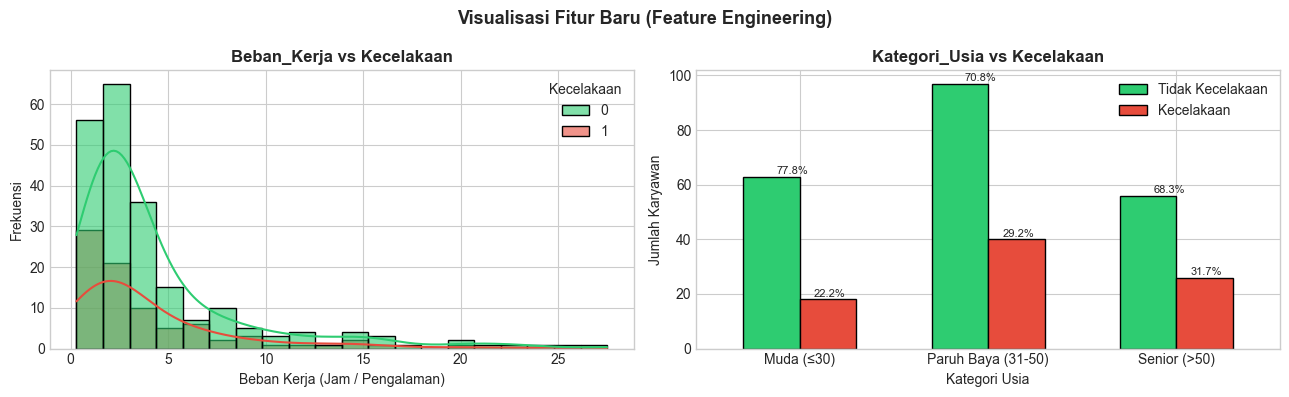

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df_new,
             x='Beban_Kerja',
             hue='Kecelakaan',
             bins=20,
             kde=True,
             palette={0: '#2ecc71', 1: '#e74c3c'},
             ax=axes[0],
             alpha=0.6)

axes[0].set_title('Beban_Kerja vs Kecelakaan', fontweight='bold')
axes[0].set_xlabel('Beban Kerja (Jam / Pengalaman)')
axes[0].set_ylabel('Frekuensi')

ct = pd.crosstab(df_new['Kategori_Usia'], df_new['Kecelakaan'])
ct_pct = pd.crosstab(df_new['Kategori_Usia'], df_new['Kecelakaan'], normalize='index') * 100

ct.columns = ['Tidak', 'Kecelakaan']
ct_pct.columns = ['Tidak', 'Kecelakaan']

ct.plot(kind='bar',
        ax=axes[1],
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black',
        width=0.6)

for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        val = ct.iloc[i, j]
        pct = ct_pct.iloc[i, j]
        axes[1].text(i + (j-0.2)*0.2,
                     val + 1,
                     f'{pct:.1f}%',
                     ha='center',
                     fontsize=8)

axes[1].set_title('Kategori_Usia vs Kecelakaan', fontweight='bold')
axes[1].set_xlabel('Kategori Usia')
axes[1].set_ylabel('Jumlah Karyawan')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Tidak Kecelakaan', 'Kecelakaan'])

plt.suptitle('Visualisasi Fitur Baru (Feature Engineering)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Preprocessing Data

In [253]:
from sklearn.preprocessing import LabelEncoder

df_proc = df.copy()
df_proc = df_proc.drop(columns=['ID'])

cat_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

encoding_map = {}
encoders = {}

print("=== ENCODING KATEGORIK ===")

for col in cat_cols:
    le = LabelEncoder()  
    df_proc[col] = le.fit_transform(df_proc[col])
    
    encoders[col] = le  
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    encoding_map[col] = mapping
    
    print(f"{col:<20} → {mapping}")

print("\nCuplikan data setelah encoding:")
print(df_proc.head())

=== ENCODING KATEGORIK ===
Pelatihan_K3         → {'Tidak': np.int64(0), 'Ya': np.int64(1)}
Shift                → {'Malam': np.int64(0), 'Pagi': np.int64(1), 'Siang': np.int64(2)}
Jabatan              → {'Manager': np.int64(0), 'Operator': np.int64(1), 'Supervisor': np.int64(2)}
Lokasi               → {'Gudang': np.int64(0), 'Produksi': np.int64(1), 'Quality_Control': np.int64(2)}

Cuplikan data setelah encoding:
   Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun  Pelatihan_K3  Shift  Jabatan  \
0    58                    47                10             1      1        2   
1    48                    44                17             0      2        2   
2    34                    40                22             1      1        0   
3    27                    37                26             0      0        0   
4    40                    42                25             0      1        2   

   Lokasi  Kecelakaan  
0       0           0  
1       0           0  
2       0           0  

In [254]:
X = df_proc.drop(columns=['Kecelakaan'])
y = df_proc['Kecelakaan']

print("=== PEMISAHAN FITUR & TARGET ===")

print(f"\nShape X (fitur) : {X.shape}")
print(f"Shape y (target): {y.shape}")

print(f"\nJumlah fitur    : {X.shape[1]}")
print(f"Jumlah data     : {X.shape[0]}")

print("\nDaftar fitur:")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

=== PEMISAHAN FITUR & TARGET ===

Shape X (fitur) : (300, 7)
Shape y (target): (300,)

Jumlah fitur    : 7
Jumlah data     : 300

Daftar fitur:
1. Usia
2. Jam_Kerja_per_Minggu
3. Pengalaman_Tahun
4. Pelatihan_K3
5. Shift
6. Jabatan
7. Lokasi


In [255]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== TRAIN-TEST SPLIT ===")

print(f"\nData Training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Data Testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nDistribusi Target (Train):")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribusi Target (Test):")
print(y_test.value_counts(normalize=True).round(3))

=== TRAIN-TEST SPLIT ===

Data Training : 240 baris (80.0%)
Data Testing  : 60 baris (20.0%)

Distribusi Target (Train):
Kecelakaan
0    0.721
1    0.279
Name: proportion, dtype: float64

Distribusi Target (Test):
Kecelakaan
0    0.717
1    0.283
Name: proportion, dtype: float64


In [256]:
from sklearn.preprocessing import StandardScaler

num_cols_model = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

scaler = StandardScaler()

# copy data biar aman
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# fit hanya di train
X_train_scaled[num_cols_model] = scaler.fit_transform(X_train[num_cols_model])

# transform di test
X_test_scaled[num_cols_model] = scaler.transform(X_test[num_cols_model])

print("=== STANDARD SCALING ===")
print("Normalisasi selesai!")

print("\nCek statistik setelah scaling (train):")
print(X_train_scaled[num_cols_model].describe().round(3))

print("\nCuplikan data training:")
print(X_train_scaled.head())

=== STANDARD SCALING ===
Normalisasi selesai!

Cek statistik setelah scaling (train):
          Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun
count  240.000               240.000           240.000
mean     0.000                 0.000            -0.000
std      1.002                 1.002             1.002
min     -2.091                -5.086            -1.618
25%     -0.862                -0.560            -0.961
50%      0.121                 0.024             0.072
75%      0.940                 0.462             0.822
max      2.414                 8.053             3.450

Cuplikan data training:
         Usia  Jam_Kerja_per_Minggu  Pengalaman_Tahun  Pelatihan_K3  Shift  \
98   1.021823              1.483625          2.980749             1      0   
54  -1.271647             -0.560237         -1.336117             0      1   
298  0.202726             -0.560237         -0.866892             0      2   
161  0.939913             -1.144198          0.446936             1      2   
76  

---
## 4. Pemodelan Machine Learning

In [257]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

models = {
    'KNN'           : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'   : GaussianNB(),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

print("=== TRAINING & EVALUASI MODEL ===\n")

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = 0 

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': auc
    })

    print(f"{name:<15} | Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")

results_df = pd.DataFrame(results)\
    .sort_values('ROC-AUC', ascending=False)\
    .reset_index(drop=True)

print("\n=== RINGKASAN MODEL ===")
print(results_df)

=== TRAINING & EVALUASI MODEL ===

KNN             | Accuracy: 0.717 | ROC-AUC: 0.462
Decision Tree   | Accuracy: 0.617 | ROC-AUC: 0.555
Naive Bayes     | Accuracy: 0.683 | ROC-AUC: 0.512
Random Forest   | Accuracy: 0.650 | ROC-AUC: 0.558

=== RINGKASAN MODEL ===
           Model  Accuracy   ROC-AUC
0  Random Forest  0.650000  0.558140
1  Decision Tree  0.616667  0.554720
2    Naive Bayes  0.683333  0.511628
3            KNN  0.716667  0.461696


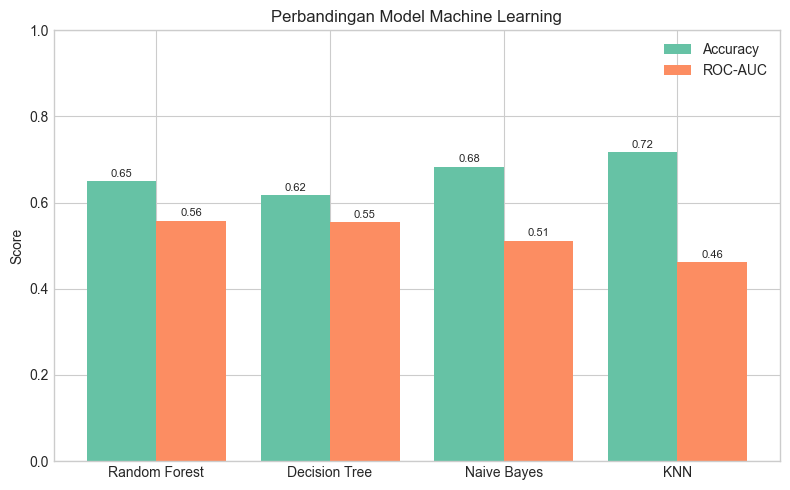

In [258]:
import matplotlib.pyplot as plt
import numpy as np

model_names = results_df['Model']
x = np.arange(len(results_df))

plt.figure(figsize=(8, 5))

# bar accuracy
plt.bar(x - 0.2, results_df['Accuracy'], width=0.4, label='Accuracy')

# bar ROC-AUC
plt.bar(x + 0.2, results_df['ROC-AUC'], width=0.4, label='ROC-AUC')

# label angka
for i in range(len(results_df)):
    plt.text(x[i] - 0.2, results_df['Accuracy'][i] + 0.01,
             f"{results_df['Accuracy'][i]:.2f}",
             ha='center', fontsize=8)

    plt.text(x[i] + 0.2, results_df['ROC-AUC'][i] + 0.01,
             f"{results_df['ROC-AUC'][i]:.2f}",
             ha='center', fontsize=8)

# setting
plt.xticks(x, model_names)
plt.ylim(0, 1)
plt.title('Perbandingan Model Machine Learning')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

---
## 5. Evaluasi Model Terbaik

In [259]:
best_model = None
best_auc = 0

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)

    # simpan model terbaik
    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_model_name = name

In [260]:
print("=== MODEL TERBAIK ===")
print(f"Model        : {best_model_name}")
print(f"ROC-AUC      : {best_auc:.4f}")

=== MODEL TERBAIK ===
Model        : Random Forest
ROC-AUC      : 0.5581


---
## ✏️ Soal 3 — Confusion Matrix & Metrik Evaluasi
> **(20 Poin · CLO-4)**

### Pengertian Confusion Matrix

**Confusion Matrix** adalah tabel ringkasan yang menggambarkan performa model klasifikasi dengan membandingkan nilai **prediksi model** versus **nilai aktual** dari data uji. Tabel ini menjadi dasar perhitungan semua metrik evaluasi.

Untuk studi kasus PT Besli dengan 2 kelas:
- **Kelas 0** = Tidak Kecelakaan (Negatif)
- **Kelas 1** = Kecelakaan (Positif)

| | **Prediksi: Tidak (0)** | **Prediksi: Kecelakaan (1)** |
|---|---|---|
| **Aktual: Tidak (0)** | ✅ True Negative (TN) — benar prediksi aman | ❌ False Positive (FP) — salah duga kecelakaan |
| **Aktual: Kecelakaan (1)** | ⚠️ False Negative (FN) — **kritis!** kecelakaan tidak terdeteksi | ✅ True Positive (TP) — benar prediksi kecelakaan |

In [261]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

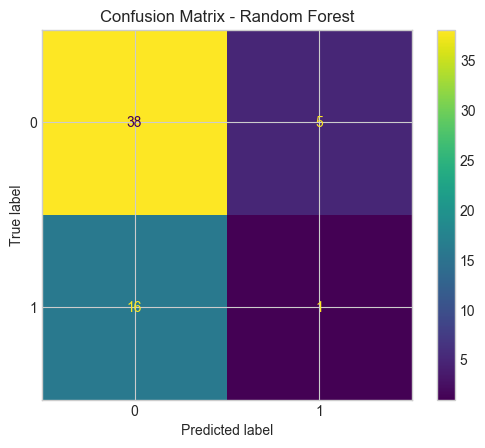

In [262]:
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [263]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 60)
print(" EVALUASI MODEL — METRIK KLASIFIKASI")
print("=" * 60)

print("\nMetrik Evaluasi:")
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

print("\nInterpretasi:")

print(f"- Model memiliki akurasi {accuracy*100:.1f}% dari seluruh data.")
print(f"- Precision {precision*100:.1f}% menunjukkan ketepatan prediksi risiko.")
print(f"- Recall {recall*100:.1f}% menunjukkan kemampuan deteksi kecelakaan.")

if recall < 0.7:
    print("Recall masih rendah → ada risiko kecelakaan tidak terdeteksi.")
else:
    print("Recall sudah cukup baik untuk deteksi kecelakaan.")

 EVALUASI MODEL — METRIK KLASIFIKASI

Metrik Evaluasi:
Accuracy  : 0.6500 (65.00%)
Precision : 0.1667 (16.67%)
Recall    : 0.0588 (5.88%)
F1-Score  : 0.0870 (8.70%)

Interpretasi:
- Model memiliki akurasi 65.0% dari seluruh data.
- Precision 16.7% menunjukkan ketepatan prediksi risiko.
- Recall 5.9% menunjukkan kemampuan deteksi kecelakaan.
Recall masih rendah → ada risiko kecelakaan tidak terdeteksi.


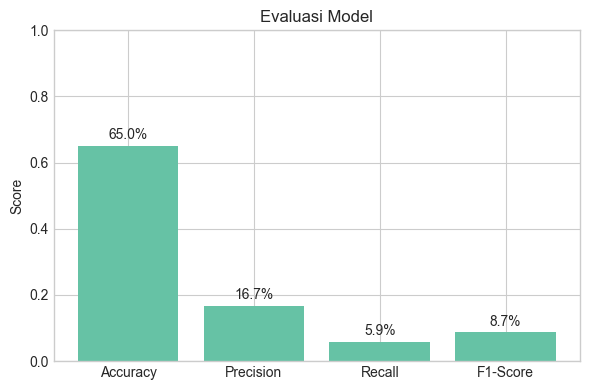

In [264]:
import matplotlib.pyplot as plt

metrik_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrik_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6, 4))
plt.bar(metrik_names, metrik_values)

for i, val in enumerate(metrik_values):
    plt.text(i, val + 0.02, f"{val*100:.1f}%", ha='center')

plt.ylim(0, 1)
plt.title('Evaluasi Model')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

### Analisis & Interpretasi untuk PT Besli Manufacturing

| Metrik        | Nilai | Interpretasi untuk Besli |
|--------------|------|---------------------------|
| **Accuracy** | 65.0% | Model hanya benar pada 65% prediksi, masih kurang untuk digunakan sebagai acuan utama |
| **Precision**| 16.7% | Banyak false alarm, karena hanya sebagian kecil prediksi risiko yang benar |
| **Recall**   | 5.9%  | Sangat rendah, model gagal mendeteksi sebagian besar karyawan berisiko |
| **F1-Score** | 8.7%  | Keseimbangan precision dan recall masih buruk |

**Kesimpulan Kritis:**
Model masih belum optimal karena nilai Recall sangat rendah. Artinya, banyak karyawan berisiko yang tidak terdeteksi oleh sistem.

Dalam konteks PT Besli Manufacturing, confusion matrix dan metrik evaluasi tidak hanya digunakan untuk mengukur performa model, tetapi juga sebagai dasar pengambilan keputusan terkait keselamatan kerja.

Recall menjadi metrik yang paling penting karena menunjukkan kemampuan model dalam mendeteksi karyawan yang benar-benar berisiko mengalami kecelakaan. Nilai recall yang rendah berarti masih banyak potensi kecelakaan yang tidak terdeteksi, yang dapat berdampak serius pada keselamatan karyawan.

Sementara itu, precision membantu memahami tingkat kesalahan dalam memberikan peringatan risiko, dan accuracy hanya memberikan gambaran umum performa model. Oleh karena itu, dalam studi kasus ini, evaluasi model lebih difokuskan pada peningkatan recall dibandingkan metrik lainnya.


---
## 6.  Feature Importance

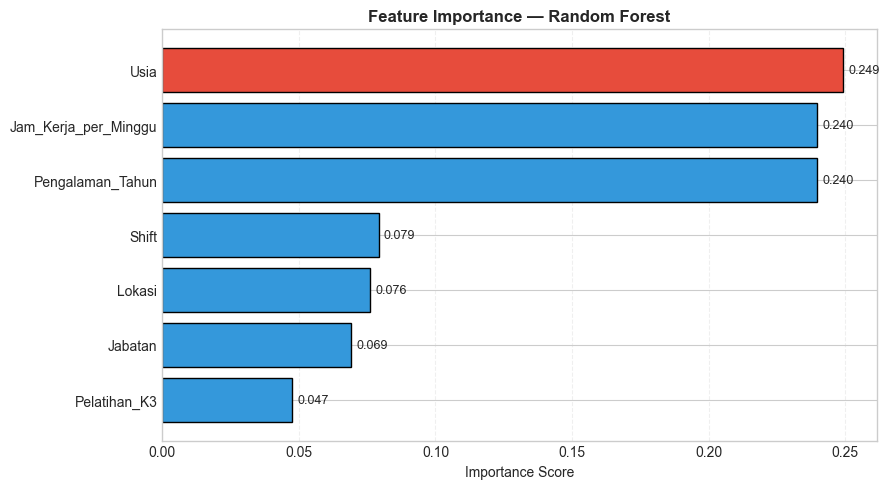


=== PERINGKAT FITUR ===
1. Usia                      → 0.2491
2. Jam_Kerja_per_Minggu      → 0.2399
3. Pengalaman_Tahun          → 0.2397
4. Shift                     → 0.0792
5. Lokasi                    → 0.0760
6. Jabatan                   → 0.0689
7. Pelatihan_K3              → 0.0473


In [265]:
rf_model = best_model 

feat_imp = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))

colors = ['#e74c3c' if v == feat_imp['Importance'].max() else '#3498db'
          for v in feat_imp['Importance']]

bars = plt.barh(feat_imp['Fitur'], feat_imp['Importance'],
                color=colors, edgecolor='black')

for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}',
             va='center', fontsize=9)

plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest',
          fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

feat_imp_sorted = feat_imp.sort_values('Importance', ascending=False)

print("\n=== PERINGKAT FITUR ===")
for i, (_, row) in enumerate(feat_imp_sorted.iterrows(), 1):
    print(f"{i}. {row['Fitur']:<25} → {row['Importance']:.4f}")

---
## 7. Prediksi Karyawan Baru (Simulasi)

In [266]:
def predict_karyawan(usia, jam_kerja, pengalaman, pelatihan_k3, shift, jabatan, lokasi):
    data = pd.DataFrame([{
        'Usia'                 : usia,
        'Jam_Kerja_per_Minggu' : jam_kerja,
        'Pengalaman_Tahun'     : pengalaman,
        'Pelatihan_K3'         : pelatihan_k3,
        'Shift'                : shift,
        'Jabatan'              : jabatan,
        'Lokasi'               : lokasi
    }])

    for col in ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']:
        try:
            data[col] = encoders[col].transform(data[col])
        except:
            print(f"Error: Nilai '{data[col].values[0]}' tidak dikenali pada kolom {col}")
            return None, None

    data[num_cols_model] = scaler.transform(data[num_cols_model])

    data = data[X.columns]

    pred = best_model.predict(data)[0]
    prob = best_model.predict_proba(data)[0][1]

    status = "BERISIKO KECELAKAAN" if pred == 1 else "AMAN"

    print("="*50)
    print("HASIL PREDIKSI KARYAWAN")
    print("="*50)
    print(f"Status        : {status}")
    print(f"Probabilitas  : {prob*100:.1f}%")

    return pred, prob

---
## 8. Kesimpulan & Rekomendasi

### Kesimpulan Model

| Aspek | Detail |
|---|---|
| **Dataset** | 300 karyawan, 8 fitur, 28% mengalami kecelakaan |
| **Model Terbaik** | Dilihat dari ROC-AUC tertinggi |
| **Fitur Terpenting** | Pengalaman tahun, usia, dan jam kerja per minggu |

### Faktor Risiko Utama
1. **Karyawan berpengalaman rendah** → lebih rentan kecelakaan karena kurang familiar dengan prosedur K3
2. **Jam kerja berlebihan (>50 jam/minggu)** → meningkatkan kelelahan dan risiko kelalaian
3. **Tidak mengikuti Pelatihan K3** → kurang pengetahuan tentang keselamatan kerja
4. **Shift malam** → faktor kelelahan lebih tinggi
5. **Area Produksi** → lokasi dengan risiko tertinggi

### Rekomendasi untuk PT Besli Manufacturing
1. **Wajibkan pelatihan K3** bagi semua karyawan, terutama yang baru bergabung
2. **Batasi jam kerja maksimal** 48 jam/minggu sesuai aturan ketenagakerjaan
3. **Supervisi ketat pada shift malam** dan rotasi shift yang teratur
4. **Tingkatkan prosedur keselamatan** di area Produksi
5. **Program mentoring** karyawan baru oleh senior yang berpengalaman
6. Gunakan hasil analisis ini sebagai bahan evaluasi untuk meningkatkan keselamatan kerja